In [157]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
import joblib

In [92]:
df = pd.read_csv('final_hateXplain.csv')

In [93]:
df.head()

,comment,label,Race,Religion,Gender,Sexual Orientation,Miscellaneous
0,0 u0 lmao wow fuck you too 😂 😂,normal,No_race,Nonreligious,No_gender,No_orientation,NaN
1,1 0 th floor maybe wow cnn with the fakenews t...,offensive,No_race,Nonreligious,No_gender,No_orientation,Other
2,1 0 yrs <number> white women raped by niggers ...,hatespeech,African,Nonreligious,No_gender,No_orientation,NaN
3,1 2 h ago ching chong accepted your friend req...,offensive,Asian,Nonreligious,No_gender,No_orientation,NaN
4,1 8 th century mayhem and lawlessness had noth...,normal,No_race,Nonreligious,No_gender,No_orientation,NaN


In [94]:
df = df.drop('Miscellaneous',axis = 1)

In [95]:
df

,comment,label,Race,Religion,Gender,Sexual Orientation
0,0 u0 lmao wow fuck you too 😂 😂,normal,No_race,Nonreligious,No_gender,No_orientation
1,1 0 th floor maybe wow cnn with the fakenews t...,offensive,No_race,Nonreligious,No_gender,No_orientation
2,1 0 yrs <number> white women raped by niggers ...,hatespeech,African,Nonreligious,No_gender,No_orientation
3,1 2 h ago ching chong accepted your friend req...,offensive,Asian,Nonreligious,No_gender,No_orientation
4,1 8 th century mayhem and lawlessness had noth...,normal,No_race,Nonreligious,No_gender,No_orientation
...,...,...,...,...,...,...
20104,😂 😂 😂 😂 😂 y ’ all be so mad at caucasians fail...,offensive,African,Nonreligious,No_gender,No_orientation
20105,🤔 🤔 🤔 🤔 mmm yes the trebuchet memes are much n...,hatespeech,Arab,Islam,No_gender,No_orientation
20106,🤣 this so ghetto i ’ m ready to get tf,offensive,No_race,Nonreligious,No_gender,No_orientation
20107,🤣 🤣 😂 😂 🤣 🤣 😂 😂 🤣 🤣 you spelled my name wrong ...,hatespeech,Arab,Nonreligious,No_gender,No_orientation


In [96]:
df.isnull().sum()

comment               0
label                 0
Race                  0
Religion              0
Gender                0
Sexual Orientation    0
dtype: int64

In [97]:
df.duplicated().sum()

np.int64(0)

In [98]:
df.info

<bound method DataFrame.info of                                                  comment       label     Race  \
0                         0 u0 lmao wow fuck you too 😂 😂      normal  No_race   
1      1 0 th floor maybe wow cnn with the fakenews t...   offensive  No_race   
2      1 0 yrs <number> white women raped by niggers ...  hatespeech  African   
3      1 2 h ago ching chong accepted your friend req...   offensive    Asian   
4      1 8 th century mayhem and lawlessness had noth...      normal  No_race   
...                                                  ...         ...      ...   
20104  😂 😂 😂 😂 😂 y ’ all be so mad at caucasians fail...   offensive  African   
20105  🤔 🤔 🤔 🤔 mmm yes the trebuchet memes are much n...  hatespeech     Arab   
20106             🤣 this so ghetto i ’ m ready to get tf   offensive  No_race   
20107  🤣 🤣 😂 😂 🤣 🤣 😂 😂 🤣 🤣 you spelled my name wrong ...  hatespeech     Arab   
20108  🤨 hm six million but yep they were disarmed ce...  hatespeech  No_race

In [99]:
df['label'].unique()

array(['normal', 'offensive', 'hatespeech'], dtype=object)

In [100]:
from sklearn.preprocessing import LabelEncoder

In [101]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [102]:
df['label'].head()

0    1
1    2
2    0
3    2
4    1
Name: label, dtype: int64

In [103]:
df['label'].unique()

array([1, 2, 0])

In [104]:
df.head()

,comment,label,Race,Religion,Gender,Sexual Orientation
0,0 u0 lmao wow fuck you too 😂 😂,1,No_race,Nonreligious,No_gender,No_orientation
1,1 0 th floor maybe wow cnn with the fakenews t...,2,No_race,Nonreligious,No_gender,No_orientation
2,1 0 yrs <number> white women raped by niggers ...,0,African,Nonreligious,No_gender,No_orientation
3,1 2 h ago ching chong accepted your friend req...,2,Asian,Nonreligious,No_gender,No_orientation
4,1 8 th century mayhem and lawlessness had noth...,1,No_race,Nonreligious,No_gender,No_orientation


In [ ]:
#EDA

In [105]:
normal = " ".join(df[df['label'] == 1]['comment'])

In [106]:
wordcloud_normal = WordCloud(width = 800, height = 400,background_color = 'pink').generate(normal)

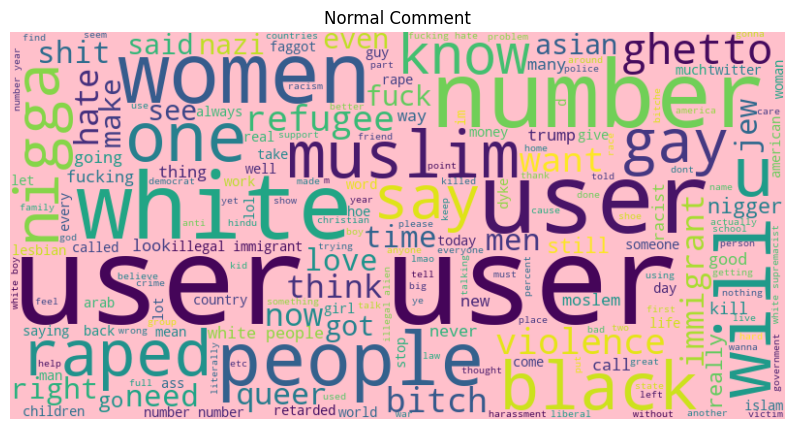

In [107]:
plt.figure(figsize = (10,6))
plt.imshow(wordcloud_normal,interpolation = 'bilinear')
plt.title('Normal Comment')
plt.axis('off')
plt.show()

In [108]:
offensive = " ".join(df[df['label'] == 2]['comment'])

In [109]:
wordcloud_offensive = WordCloud(width = 800, height = 400,background_color = 'pink').generate(offensive)

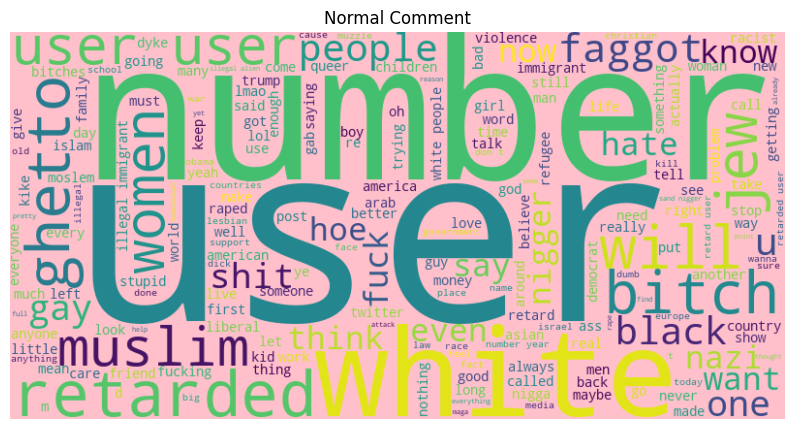

In [110]:
plt.figure(figsize = (10,6))
plt.imshow(wordcloud_offensive,interpolation = 'bilinear')
plt.title('Normal Comment')
plt.axis('off')
plt.show()

In [111]:
hatespeech = " ".join(df[df['label'] == 0]['comment'])

In [112]:
wordcloud_hatespeech = WordCloud(width = 800, height = 400,background_color = 'pink').generate(hatespeech)

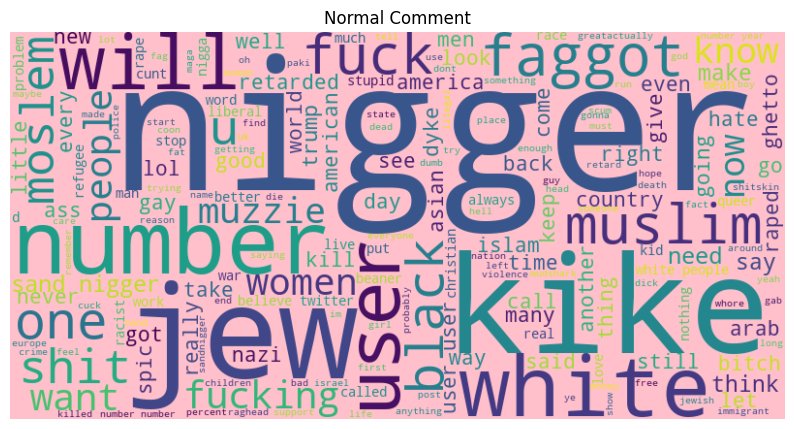

In [113]:
plt.figure(figsize = (10,6))
plt.imshow(wordcloud_hatespeech,interpolation = 'bilinear')
plt.title('Normal Comment')
plt.axis('off')
plt.show()

In [ ]:
#text cleaning

In [116]:
import re
clean = re.compile(r'</!.*?>')

In [117]:
re.sub(clean,"",df.iloc[2].comment)

'1 0 yrs <number> white women raped by niggers <number> negress raped by a cracker source fbi crime stats wake up rise up'

In [118]:
def clean_html_text(text):
    text = re.sub(clean," ",text)
    return text
df['comment'] = df['comment'].apply(clean_html_text)

In [119]:
clean = re.compile('!/</''.*?>')

In [120]:
def clean_text(text):
    text = re.sub(clean," ",text)
    return text
df['comment'] = df['comment'].apply(clean_text)

In [121]:
def lower_case(text):
    return text.lower()

In [122]:
df['comment'] = df['comment'].apply(lower_case)

In [123]:
import nltk

In [124]:
from nltk.corpus import stopwords

In [125]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = []
    for word in text.split():
        if word not in stop_words:
            words.append(word)
    return " ".join(words)

df['comment'] = df['comment'].apply(remove_stopwords)

In [126]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [127]:
def stem_words(text):
    y = []

    for i in text.split():
        y.append(ps.stem(i))

    return " ".join(y)

df['comment'] = df['comment'].apply(stem_words)

In [128]:
def remove_special(text):
    x = ' '
    for i in text:
        if i.isalnum():
            x = x +i
        else:
            x = x + ' '
    return x

df['comment'] = df['comment'].apply(remove_special)

In [129]:
df['comment'].head()

0                               0 u0 lmao wow fuck    
1     1 0 th floor mayb wow cnn fakenew bodi count ...
2     1 0 yr  number  white women rape nigger  numb...
3       1 2 h ago ching chong accept friend request   
4     1 8 th centuri mayhem lawless noth loud mouth...
Name: comment, dtype: object

In [133]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features= 1000)

In [158]:
X = cv.fit_transform(df['comment']).toarray()
joblib.dump(cv,'Vectorizer.pkl')

['Vectorizer.pkl']

In [137]:
X.shape

(20109, 1000)

In [139]:
y = df['label'].values

In [146]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [142]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [147]:
model1 = GaussianNB()
model1.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [148]:
y_pred1 = model1.predict(X_test)

In [149]:
model2 = MultinomialNB()
model2.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [150]:
y_pred2 = model2.predict(X_test)

In [151]:
model3 = BernoulliNB()
model3.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


In [152]:
y_pred3 = model3.predict(X_test)

In [153]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [154]:
print("Gaussian:",accuracy_score(y_test,y_pred1)) 
print("Multinomial:",accuracy_score(y_test,y_pred2))
print("BernoulliNB:",accuracy_score(y_test,y_pred3))

Gaussian: 0.5049726504226753
Multinomial: 0.6220785678766783
BernoulliNB: 0.6190949776230731


In [155]:
print("Gaussian:",confusion_matrix(y_test,y_pred1)) 
print("Multinomial:",confusion_matrix(y_test,y_pred2))
print("BernoulliNB:",confusion_matrix(y_test,y_pred3))

Gaussian: [[ 627  396  302]
 [ 196 1082  224]
 [ 263  610  322]]
Multinomial: [[ 919  223  183]
 [ 161 1085  256]
 [ 257  440  498]]
BernoulliNB: [[ 907  234  184]
 [ 134 1093  275]
 [ 242  463  490]]


In [156]:
print("Gaussian:",classification_report(y_test,y_pred1)) 
print("Multinomial:",classification_report(y_test,y_pred2))
print("BernoulliNB:",classification_report(y_test,y_pred3))

Gaussian:               precision    recall  f1-score   support

           0       0.58      0.47      0.52      1325
           1       0.52      0.72      0.60      1502
           2       0.38      0.27      0.32      1195

    accuracy                           0.50      4022
   macro avg       0.49      0.49      0.48      4022
weighted avg       0.50      0.50      0.49      4022

Multinomial:               precision    recall  f1-score   support

           0       0.69      0.69      0.69      1325
           1       0.62      0.72      0.67      1502
           2       0.53      0.42      0.47      1195

    accuracy                           0.62      4022
   macro avg       0.61      0.61      0.61      4022
weighted avg       0.62      0.62      0.62      4022

BernoulliNB:               precision    recall  f1-score   support

           0       0.71      0.68      0.70      1325
           1       0.61      0.73      0.66      1502
           2       0.52      0.41      

In [159]:
joblib.dump(model3, "model.pkl")

['model.pkl']